# **MS Challenge: Buscador de Arte Semántico**

# Análisis del dataset del Rijksmuseum

En este notebook se realiza un análisis del dataset del [Rijksmuseum](https://www.kaggle.com/datasets/lgmoneda/rijksmuseum) que está disponible públicamente en Kaggle y que vamos a utilizar para este challenge.

## Librerías necesarias

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
from PIL import Image
import seaborn as sns
from tqdm import tqdm


## Carga del dataset

El dataset está compuesto por un csv de metadatos y una serie de carpetas que contienen las imágenes de los distintos tipos de obras de arte. De un primer vistazo podemos ver que la información de todas las obras viene recogida en el fichero 'metadata.csv', que tiene un identificador único para cada obra, su título, artista, fecha de finalización y tipo. El identificador único será muy útil para poder unir cada obra de arte (almacenada en una subcarpeta concreta) con sus metadatos y, su información podremos almacenarla y mostrarla en el sistema una vez se haga la recuperación de las imágenes.

Además, podemos ver que en total hay 24564 obras de arte distintas organizadas según su tipo, que puede ser 'painting', 'photograph', 'photomechanical print' o 'drawing'.



In [3]:
desired_path = "../dataset"
os.makedirs(desired_path, exist_ok=True)
destination_dir = os.path.join(desired_path, "rijksmuseum")
# Cargar el dataset
dataset_root_dir = os.path.join(destination_dir, "rijksmuseum")
data_path = os.path.join(dataset_root_dir, "metadata.csv")
df = pd.read_csv(data_path)

# Mostremos qué tiene el dataset en sus columnas
print(df.columns)

# Mostrar las carpetas dentro del dataset
folders = [f for f in os.listdir(dataset_root_dir) if os.path.isdir(os.path.join(dataset_root_dir, f))]
print("Carpetas en la subcarpeta del dataset ('rijksmuseum'):", folders)

# Mostrar el número total de elementos dentro de todas las carpetas de la subcarpeta del dataset.
total_items_in_subfolders = sum(len(os.listdir(os.path.join(dataset_root_dir, folder))) for folder in folders)
print("Número total de elementos en todas las carpetas dentro de 'rijksmuseum':", total_items_in_subfolders)
print("Número total de entradas en el dataset (metadata.csv):", len(df))

Index(['Unnamed: 0', 'id', 'title', 'artist', 'date', 'type'], dtype='str')
Carpetas en la subcarpeta del dataset ('rijksmuseum'): ['painting', 'photograph', 'photomechanical print', 'drawing']
Número total de elementos en todas las carpetas dentro de 'rijksmuseum': 24554
Número total de entradas en el dataset (metadata.csv): 24564


## Análisis del dataset

Como hemos visto, el dataset está compuesto por 24564 obras de arte y, solamente hay una fila con un valor nulo en la columna artista. Dado que solamente falta un único dato para una de las casi 25000 obras y que para el proyecto que estamos desarrollando los metadatos no tienen un papel relevante, más allá de mostrarle la información de la imágenes recuperadas al usuario, no será necesario realizar ningún preprocesamiento mucho más detallado sobre el conjunto de datos.

Por otro lado, como veremos más adelante, debido al gran número de imágenes que componen el dataset, seguramente sea necesario tomar un subconjunto de ellas.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24564 entries, 0 to 24563
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  24564 non-null  int64
 1   id          24564 non-null  str  
 2   title       24564 non-null  str  
 3   artist      24563 non-null  str  
 4   date        24564 non-null  str  
 5   type        24564 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.1 MB


A continuación se muestran los primeros elementos del csv de metadatos. Podemos ver que el csv se compone de estas 6 columnas:

- Unnamed (índice): índice de cada fila del dataset
- id: identificador de cada obra artística. Sirve para poder relacionar los metadatos con la imágen correspondiente.
- title: título o nombre de la obra de arte.
- artist: Muestra el nombre del creador, artista o fotógrafo de la obra (en los casos en los que se desconoce, aparece como anonymous).
- date: año o periodo estimado en el que se creó la obra.
- type: describe el tipo de obra. Puede ser painting, photomechanical print, photograph o drawing.

In [5]:
df.head()

,Unnamed: 0,id,title,artist,date,type
0,0,SK-A-1849,"The Frederiksplein, Amsterdam, during the Entr...",Otto Eerelman,1898 - 1900,painting
1,1,RP-F-2001-7-230-3,Somersby Church,C.J. Caswell,c. 1884 - in or before 1889,photomechanical print
2,2,RP-F-2001-7-118-17,"Twaalf mannenhoofden in vooraanzicht, gerangsc...",anonymous,c. 1880 - in or before 1893,photomechanical print
3,3,RP-F-F25401-AB,Colossi and sphynx at Wady Saboua - Nubia,Francis Frith,1857,photograph
4,4,RP-F-F25412-R,Roslin Chapel; 'Prentice Pillar,George Washington Wilson,c. 1855 - c. 1862,photograph


### Distribución de los distintos tipos de obra

Antes de comenzar con el desarrollo del sistema, es importante ver la distribución de los datos para evitar cualquier sesgo de representación o predominancia de un tipo de obra concreto por encima de otros. 

A continuación, se muestra la distribución de los distintos tipos de obra y, en primer lugar, vemos que los más predominantes son 'drawing' y 'photomechanical print', por lo que hay un desbalanceo claro entre las distintas clases. Por ello, con el objetivo de buscar un equilibrio entre que el sistema tenga un buen rendimiento y de que haya una representación equitativa de todos los tipos de obra, vamos a tomar un subconjunto de 4000 imágenes en total, donde tengamos 1000 obras (seleccionadas aleatoriamente) de cada uno de los tipos. De esta forma, podremos construir un sistema lo suficientemente representativo y, escalable en un futuro, a la vez que evitamos que solamente se recuperen obras de un tipo determinado y eso afecte al funcionamiento del sistema y a la satisfacción de los usuarios.

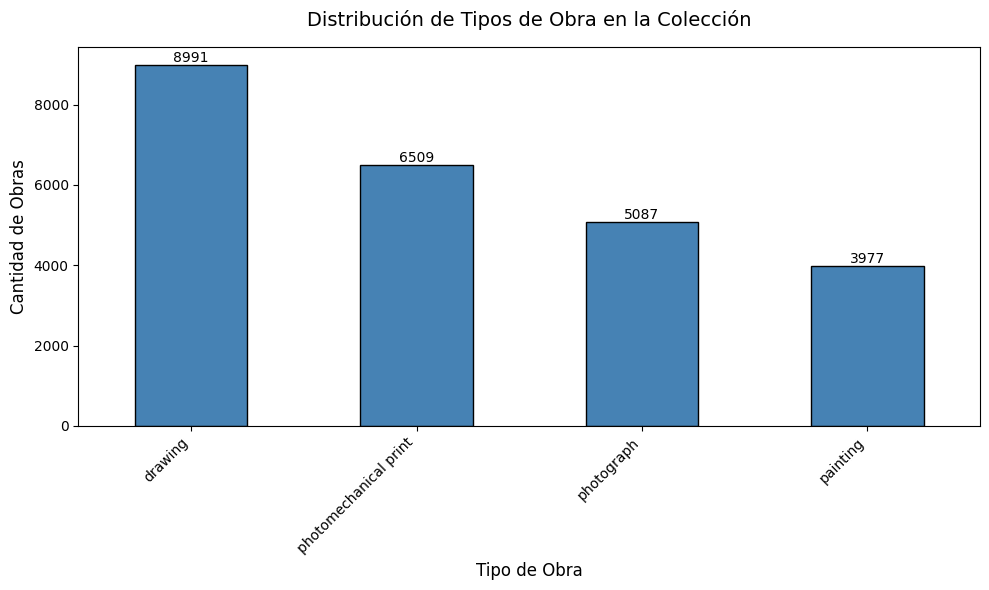

In [6]:

plt.figure(figsize=(10, 6))

ax = df["type"].value_counts().plot(
    kind='bar', 
    color='steelblue', 
    edgecolor='black'
)

plt.title('Distribución de Tipos de Obra en la Colección', fontsize=14, pad=15)
plt.xlabel('Tipo de Obra', fontsize=12)
plt.ylabel('Cantidad de Obras', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.savefig('distribucion_tipos_real.png', dpi=300)
plt.show()

### Análisis de la dimensión de las imágenes

Para finalizar el análisis exploratorio del corpus de imágenes, queremos comprobar si alguno de los archivos está corrupto y no se puede abrir para no tenerlo en cuenta a la hora de hacer la selección de las 1000 imágenes de cada tipo, además de analizar la dimensión de las distintas imágenes por si fuera necesario algún tipo de preprocesamiento.

Respecto a los archivos, el siguiente código ha podido acceder a todos excepto a uno ('../dataset/rijksmuseum/rijksmuseum/drawing/RP-T-1940-571.jpg'), por lo que lo eliminaremos del dataset y no lo tendremos en cuenta a la hora de crear el subconjunto de 4000 imágenes que utilizaremos para el desarrollo del RAG multimodal, evitando así cualquier error durante las fases de ingesta o recuperación.

En cuanto a la dimensión y resolución de las obras, los gráficos generados nos hacen pensar que los creadores del dataset ya han hecho algún tipo de preprocesamiento o estandarización de las imágenes para que su uso sea mucho más directo:

Distribución de la relación de aspecto (Histograma): El conjunto de datos contiene imágenes con distintos formatos, entre los que encontramos un pico mayoritario justo por debajo de la relación de aspecto 1:1 (cuadrado), lo que indica una clara presencia de obras en formato vertical. Un segundo pico, algo más suave, se sitúa entre el 1.2 y el 1.5, agrupando las obras en formato horizontal o apaisado. Por lo general, no encontramos valores que sean muy extremos, lo que confirma que no tendremos que trabajar con imágenes excesivamente panorámicas que pudieran ser mal interpretadas por el VLM, lo que facilita notablemente el trabajo.

Ancho vs Alto de las imágenes: En el gráfico de dispersión podemos ver claramente que la mayoría de imágenes tiene un ancho de 1000 píxeles, lo que probablemente signifique que este corpus de imágenes de Kaggle ya ha pasado por un proceso de estandarización y redimensionado previo. En general, las mayoría de las resoluciones se encuentran en un rango de 250 a 2500 píxeles de alto, lo que supone una ventaja para el proyecto, ya que las imágenes tienen la calidad y resolución suficientes para que el VLM extraiga los matices artísticos y semánticos necesarios, permitiendo una correcta recuperación de obras de arte en base a su significado semántico.

Se encontraron 24554 imágenes en total.


 87%|████████▋ | 21315/24554 [00:05<00:00, 3587.38it/s]

Error leyendo ../dataset/rijksmuseum/rijksmuseum/drawing/RP-T-1940-571.jpg: cannot identify image file '../dataset/rijksmuseum/rijksmuseum/drawing/RP-T-1940-571.jpg'


100%|██████████| 24554/24554 [00:06<00:00, 3654.98it/s]



--- Resumen Estadístico ---
              width        height  aspect_ratio  resolution_megapixels
count  24553.000000  24553.000000  24553.000000           24553.000000
mean     999.310105    995.290799      1.152930               0.993551
std       18.861065    368.118089      0.443721               0.363799
min      194.000000    123.000000      0.077600               0.123000
25%     1000.000000    681.000000      0.765111               0.681000
50%     1000.000000    822.000000      1.216545               0.821000
75%     1000.000000   1307.000000      1.468429               1.307000
max     1000.000000   3894.000000      8.130081               3.060684


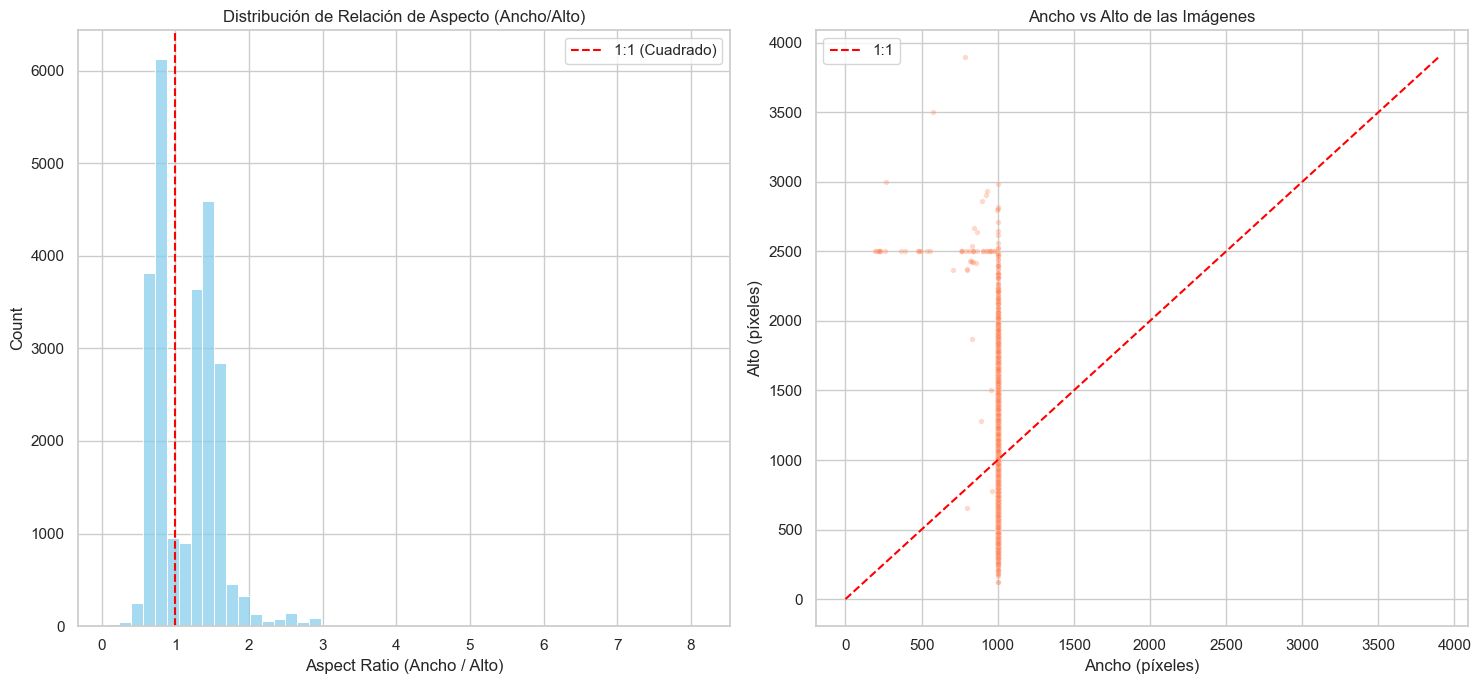

In [ ]:
IMAGE_FOLDER = "../dataset/rijksmuseum/" 
extensions = ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff", "*.JPG", "*.PNG"]

image_paths = []
for ext in extensions:
    # Recorrer todos los subdirectorios
    rutas = glob.glob(os.path.join(IMAGE_FOLDER, f"**/{ext}"), recursive=True)
    image_paths.extend(rutas)

print(f"Se encontraron {len(image_paths)} imágenes en total.")
# Obtener info de las imágenes
data = []
for path in tqdm(image_paths):
    try:
        with Image.open(path) as img:
            width, height = img.size
            data.append({"filename": os.path.basename(path), "width": width, "height": height})
    except Exception as e:
        print(f"Error leyendo {path}: {e}")

df_sizes = pd.DataFrame(data)

df_sizes['aspect_ratio'] = df_sizes['width'] / df_sizes['height']
df_sizes['resolution_megapixels'] = (df_sizes['width'] * df_sizes['height']) / 1_000_000

# Guardamos el resumen estadístico
print("\n--- Resumen Estadístico ---")
print(df_sizes.describe())
df_sizes.to_csv("analisis_dimensiones_rijksmuseum.csv", index=False)

# Gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Histograma de Aspect Ratio
sns.histplot(df_sizes['aspect_ratio'], bins=50, ax=axes[0], color='skyblue')
axes[0].axvline(1.0, color='red', linestyle='--', label='1:1 (Cuadrado)')
axes[0].set_title('Distribución de Relación de Aspecto (Ancho/Alto)')
axes[0].set_xlabel('Aspect Ratio (Ancho / Alto)')
axes[0].legend()

# Scatter Plot (Ancho vs Alto)
sns.scatterplot(x='width', y='height', data=df_sizes, alpha=0.3, ax=axes[1], color='coral', s=15)
# Línea de proporción cuadrada
max_val = max(df_sizes['width'].max(), df_sizes['height'].max())
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='1:1')
axes[1].set_title('Ancho vs Alto de las Imágenes')
axes[1].set_xlabel('Ancho (píxeles)')
axes[1].set_ylabel('Alto (píxeles)')
axes[1].legend()


plt.tight_layout()
plt.savefig('rijksmuseum_dimension_analysis.png', dpi=300)
plt.show()